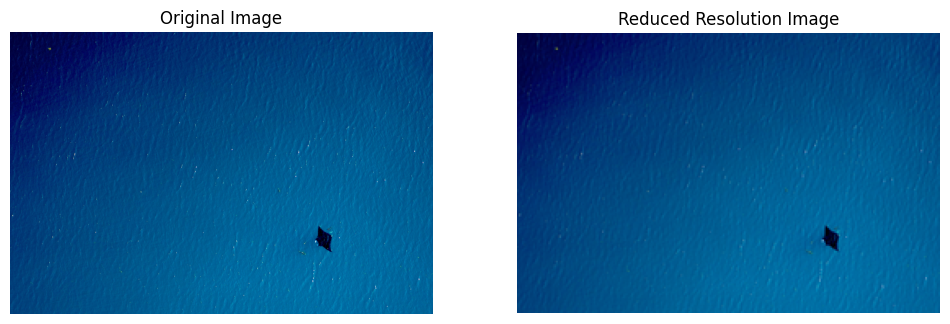

Reduced resolution image saved to: C:\MS_2024\Marine Stages\Airial images from NOAA\Yolo training satalight quality\images\train row input\group 1 out\2022-01-12_B2212579_mara_unsh_Alt600 color adjust.JPG


In [2]:
from PIL import Image
import matplotlib.pyplot as plt
import os

# Path to your image
image_path = r"C:\MS_2024\Marine Stages\Airial images from NOAA\Yolo training satalight quality\images\train row input\Group1\2022-01-12_B2212579_mara_unsh_Alt600 color adjust.JPG"
output_dir = r"C:\MS_2024\Marine Stages\Airial images from NOAA\Yolo training satalight quality\images\train row input\group 1 out"

# Ensure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Load the original image
original_image = Image.open(image_path)

# Downscale factor
downscale_factor = 0.05  # Adjust the scale down factor as needed

# Resize image
new_size = (int(original_image.width * downscale_factor), int(original_image.height * downscale_factor))
reduced_image = original_image.resize(new_size, Image.Resampling.LANCZOS)

# Save the reduced resolution image to the output folder
output_image_path = os.path.join(output_dir, os.path.basename(image_path))
reduced_image.save(output_image_path)

# Display both original and reduced images
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Original image
ax[0].imshow(original_image)
ax[0].set_title('Original Image')
ax[0].axis('off')

# Reduced resolution image
ax[1].imshow(reduced_image)
ax[1].set_title('Reduced Resolution Image')
ax[1].axis('off')

plt.show()

# Print message confirming save location
print(f"Reduced resolution image saved to: {output_image_path}")


In [5]:
import os
from PIL import Image

# Paths for the image, labels, and output directories
image_dir = r"C:\MS_2024\Marine Stages\Airial images from NOAA\Yolo training satalight quality\images\train row input\Group 2"
label_dir = r"C:\MS_2024\Marine Stages\Airial images from NOAA\YOLO_training_9_24_2024\labels\train"
output_image_dir = r"C:\MS_2024\Marine Stages\Airial images from NOAA\Yolo training satalight quality\images\train row input\group 2 out_images"
output_label_dir = r"C:\MS_2024\Marine Stages\Airial images from NOAA\Yolo training satalight quality\images\train row input\group 2 out lable"
unlabeled_image_dir = r"C:\MS_2024\Marine Stages\Airial images from NOAA\Yolo training satalight quality\images\train row input\group 2 no labels_images"

# Ensure output directories exist
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)
os.makedirs(unlabeled_image_dir, exist_ok=True)

# Downscale factor
downscale_factor = 0.05  # Adjust as needed

# Get list of all images in the image directory
image_files = [f for f in os.listdir(image_dir) if f.endswith('.JPG')]

# Loop over all images and corresponding labels
for image_file in image_files:
    # Image and label paths
    image_path = os.path.join(image_dir, image_file)
    label_filename = image_file.replace('.JPG', '.txt')  # Assuming YOLOv8 labels are in .txt format
    label_path = os.path.join(label_dir, label_filename)

    # Load the original image
    original_image = Image.open(image_path)
    image_width, image_height = original_image.size

    # Downscale the image
    new_size = (int(image_width * downscale_factor), int(image_height * downscale_factor))
    downscaled_image = original_image.resize(new_size, Image.Resampling.LANCZOS)

    # Check if the label file exists
    if os.path.exists(label_path):
        # Load YOLOv8 label file
        with open(label_path, 'r') as f:
            labels = f.readlines()

        # YOLO format: class_id, x_center, y_center, width, height (normalized)
        new_labels = []
        for label in labels:
            label_data = label.split()
            class_id = int(label_data[0])
            x_center_norm = float(label_data[1])
            y_center_norm = float(label_data[2])
            width_norm = float(label_data[3])
            height_norm = float(label_data[4])

            # Convert normalized coordinates to pixel values on the original image
            x_center = x_center_norm * image_width
            y_center = y_center_norm * image_height
            box_width = width_norm * image_width
            box_height = height_norm * image_height

            # Calculate the top-left and bottom-right corners of the bounding box
            top_left_x = x_center - (box_width / 2)
            top_left_y = y_center - (box_height / 2)
            bottom_right_x = x_center + (box_width / 2)
            bottom_right_y = y_center + (box_height / 2)

            # Now, apply the downscaling factor to the bounding box coordinates
            top_left_x_downscaled = top_left_x * downscale_factor
            top_left_y_downscaled = top_left_y * downscale_factor
            bottom_right_x_downscaled = bottom_right_x * downscale_factor
            bottom_right_y_downscaled = bottom_right_y * downscale_factor

            # Recalculate the center, width, and height for the downscaled image
            new_x_center = (top_left_x_downscaled + bottom_right_x_downscaled) / 2
            new_y_center = (top_left_y_downscaled + bottom_right_y_downscaled) / 2
            new_box_width = bottom_right_x_downscaled - top_left_x_downscaled
            new_box_height = bottom_right_y_downscaled - top_left_y_downscaled

            # Normalize the new bounding box parameters for the downscaled image
            new_x_center_norm = new_x_center / new_size[0]
            new_y_center_norm = new_y_center / new_size[1]
            new_width_norm = new_box_width / new_size[0]
            new_height_norm = new_box_height / new_size[1]

            # Add the new label in YOLO format (class_id, new_x_center_norm, new_y_center_norm, new_width_norm, new_height_norm)
            new_label = f"{class_id} {new_x_center_norm:.6f} {new_y_center_norm:.6f} {new_width_norm:.6f} {new_height_norm:.6f}"
            new_labels.append(new_label)

        # Save the new labels to the output label directory
        output_label_path = os.path.join(output_label_dir, label_filename)
        with open(output_label_path, 'w') as f:
            for new_label in new_labels:
                f.write(new_label + '\n')

        # Save the downscaled image to the output directory for labeled images
        output_image_path = os.path.join(output_image_dir, image_file)
        downscaled_image.save(output_image_path)

        # Print a message indicating successful processing for labeled images
        print(f"Processed and saved labeled image and labels for: {image_file}")
    else:
        # If no label exists, save the downscaled image in the "unlabeled" directory
        unlabeled_image_path = os.path.join(unlabeled_image_dir, image_file)
        downscaled_image.save(unlabeled_image_path)

        # Print a message indicating successful processing for unlabeled images
        print(f"Processed and saved unlabeled image for: {image_file}")


Processed and saved labeled image and labels for: Copy of MARA-19May15_IMG_1555-509 color adjust.JPG
Processed and saved labeled image and labels for: Copy of MARA-19May15_IMG_1555-509.JPG
Processed and saved labeled image and labels for: Copy of MaRa-20APR16-12 color adjust.JPG
Processed and saved labeled image and labels for: Copy of MaRa-20APR16-12.JPG
Processed and saved labeled image and labels for: Copy of MaRa-24APR16-53 color adjust.JPG
Processed and saved labeled image and labels for: Copy of MaRa-24APR16-53.JPG
Processed and saved labeled image and labels for: Copy of MR-03Apr12-012 color adjust.JPG
Processed and saved labeled image and labels for: Copy of MR-03Apr12-012.JPG
Processed and saved labeled image and labels for: Copy of MR-10Apr12-002 color adjust.JPG
Processed and saved labeled image and labels for: Copy of MR-10Apr12-002.JPG
Processed and saved labeled image and labels for: Copy of MR-11Apr11-054 color adjust.JPG
Processed and saved labeled image and labels for: